<span style="font-family: 'Times New Roman', Times, serif; line-height: 1.2;">

# 01 - Feature Dataset Analysis

This notebook analyzes multiple Spotify feature datasets to understand their coverage and overlap with the Million Playlist Dataset (MPD). We examine 12 different feature sources to determine which datasets provide the best coverage for our recommendation system.

## 1. Setup and Data Loading

Loading all available feature datasets and the MPD playlist data.

</span>

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
from tqdm.auto import tqdm

import sys
sys.path.append(str(Path("..").resolve()))
from src.data_utils import extract_track_id_from_uri, get_id_set, load_mpd_track_ids, calculate_overlap_stats


PROJECT_ROOT = Path("..").resolve()
DATA_RAW = PROJECT_ROOT / "data" / "raw"

TRACKS_FEATURES_PATH      = DATA_RAW / "tracks_features.csv"
SPOTIFY_DATA_PATH         = DATA_RAW / "spotify_data.csv"
SPOTIFY_2023_PATH         = DATA_RAW / "spotify_features_data_2023.csv"
TRACKS_PATH               = DATA_RAW / "tracks.csv"
PATH_278K                 = DATA_RAW / "278k_labelled_uri.csv"
DATA_PATH                 = DATA_RAW / "data.csv"
RAW_SONGS_PATH            = DATA_RAW / "raw songs dataset.csv"
APRIL_2019_PATH           = DATA_RAW / "SpotifyAudioFeaturesApril2019.csv"
MUSIC_INFO_PATH           = DATA_RAW / "Music Info.csv"
MUSIC_PATH                = DATA_RAW / "Music.csv"
SONGS_AUDIO_FEAT_PATH     = DATA_RAW / "songs_with_audio_feature.csv"
DATASET_2MIL_PATH         = DATA_RAW / "2mil_dataset.json"
MPD_DIR                   = DATA_RAW / "mpd" / "data"

(
    TRACKS_FEATURES_PATH,
    SPOTIFY_DATA_PATH,
    SPOTIFY_2023_PATH,
    TRACKS_PATH,
    PATH_278K,
    DATA_PATH,
    RAW_SONGS_PATH,
    APRIL_2019_PATH,
    MUSIC_INFO_PATH,
    MUSIC_PATH,
    SONGS_AUDIO_FEAT_PATH,
    DATASET_2MIL_PATH,
    MPD_DIR,
)


c:\Users\Kiera\Music_Recommender\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(WindowsPath('C:/Users/Kiera/Music_Recommender/data/raw/tracks_features.csv'),
 WindowsPath('C:/Users/Kiera/Music_Recommender/data/raw/spotify_data.csv'),
 WindowsPath('C:/Users/Kiera/Music_Recommender/data/raw/spotify_features_data_2023.csv'),
 WindowsPath('C:/Users/Kiera/Music_Recommender/data/raw/tracks.csv'),
 WindowsPath('C:/Users/Kiera/Music_Recommender/data/raw/278k_labelled_uri.csv'),
 WindowsPath('C:/Users/Kiera/Music_Recommender/data/raw/data.csv'),
 WindowsPath('C:/Users/Kiera/Music_Recommender/data/raw/raw songs dataset.csv'),
 WindowsPath('C:/Users/Kiera/Music_Recommender/data/raw/SpotifyAudioFeaturesApril2019.csv'),
 WindowsPath('C:/Users/Kiera/Music_Recommender/data/raw/Music Info.csv'),
 WindowsPath('C:/Users/Kiera/Music_Recommender/data/raw/Music.csv'),
 WindowsPath('C:/Users/Kiera/Music_Recommender/data/raw/songs_with_audio_feature.csv'),
 WindowsPath('C:/Users/Kiera/Music_Recommender/data/raw/2mil_dataset.json'),
 WindowsPath('C:/Users/Kiera/Music_Recommender/data/ra

In [2]:
tracks_features_df = pd.read_csv(TRACKS_FEATURES_PATH)
spotify_data_df    = pd.read_csv(SPOTIFY_DATA_PATH)
spotify_2023_df    = pd.read_csv(SPOTIFY_2023_PATH)
tracks_df          = pd.read_csv(TRACKS_PATH)
k278_df            = pd.read_csv(PATH_278K)
data_df            = pd.read_csv(DATA_PATH)
raw_songs_df       = pd.read_csv(RAW_SONGS_PATH)
april_2019_df      = pd.read_csv(APRIL_2019_PATH)
music_info_df      = pd.read_csv(MUSIC_INFO_PATH)
music_df           = pd.read_csv(MUSIC_PATH)
songs_audio_df     = pd.read_csv(SONGS_AUDIO_FEAT_PATH)

# 2M JSON – load as a list of dicts then to DataFrame
with open(DATASET_2MIL_PATH, "r", encoding="utf-8") as f:
    data_2mil = json.load(f)
dataset_2mil_df = pd.DataFrame(data_2mil)


<span style="font-family: 'Times New Roman', Times, serif; line-height: 1.2;">

## 2. Initial Data Inspection

Quick view of all dataset structures to understand available columns.
</span>

In [3]:
print("tracks_features.csv shape:                ", tracks_features_df.shape)
print("spotify_data.csv shape:                   ", spotify_data_df.shape)
print("spotify_features_data_2023.csv shape:     ", spotify_2023_df.shape)
print("tracks.csv shape:                         ", tracks_df.shape)
print("278k_labelled_uri.csv shape:              ", k278_df.shape)
print("data.csv shape:                           ", data_df.shape)
print("raw songs dataset.csv shape:              ", raw_songs_df.shape)
print("SpotifyAudioFeaturesApril2019.csv shape:  ", april_2019_df.shape)
print("Music Info.csv shape:                     ", music_info_df.shape)
print("Music.csv shape:                          ", music_df.shape)
print("songs_with_audio_feature.csv shape:       ", songs_audio_df.shape)
print("2mil_dataset.json (rows) shape:           ", dataset_2mil_df.shape)

display(tracks_features_df.head(2))
display(spotify_data_df.head(2))
display(spotify_2023_df.head(2))
display(tracks_df.head(2))
display(k278_df.head(2))
display(data_df.head(2))
display(raw_songs_df.head(2))
display(april_2019_df.head(2))
display(music_info_df.head(2))
display(music_df.head(2))
display(songs_audio_df.head(2))
display(dataset_2mil_df.head(2))


tracks_features.csv shape:                 (1204025, 24)
spotify_data.csv shape:                    (1159764, 20)
spotify_features_data_2023.csv shape:      (438112, 18)
tracks.csv shape:                          (586672, 20)
278k_labelled_uri.csv shape:               (277938, 15)
data.csv shape:                            (170653, 19)
raw songs dataset.csv shape:               (67499, 32)
SpotifyAudioFeaturesApril2019.csv shape:   (130663, 17)
Music Info.csv shape:                      (50683, 21)
Music.csv shape:                           (65795, 20)
songs_with_audio_feature.csv shape:        (35200, 21)
2mil_dataset.json (rows) shape:            (2305616, 14)


,id,name,album,album_id,artists,artist_ids,track_number,disc_number,explicit,danceability,...,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,year,release_date
0,7lmeHLHBe4nmXzuXc0HDjk,Testify,The Battle Of Los Angeles,2eia0myWFgoHuttJytCxgX,['Rage Against The Machine'],['2d0hyoQ5ynDBnkvAbJKORj'],1,1,False,0.470,...,0.0727,0.0261,0.000011,0.356,0.503,117.906,210133,4.0,1999,1999-11-02
1,1wsRitfRRtWyEapl0q22o8,Guerrilla Radio,The Battle Of Los Angeles,2eia0myWFgoHuttJytCxgX,['Rage Against The Machine'],['2d0hyoQ5ynDBnkvAbJKORj'],2,1,True,0.599,...,0.1880,0.0129,0.000071,0.155,0.489,103.680,206200,4.0,1999,1999-11-02


,Unnamed: 0,artist_name,track_name,track_id,popularity,year,genre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature
0,0,Jason Mraz,I Won't Give Up,53QF56cjZA9RTuuMZDrSA6,68,2012,acoustic,0.483,0.303,4,-10.058,1,0.0429,0.694,0.000000,0.1150,0.139,133.406,240166,3
1,1,Jason Mraz,93 Million Miles,1s8tP3jP4GZcyHDsjvw218,50,2012,acoustic,0.572,0.454,3,-10.286,1,0.0258,0.477,0.000014,0.0974,0.515,140.182,216387,4


,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,type,id,uri,track_href,analysis_url,duration_ms,time_signature
0,0.460,0.125,11,-8.094,0,0.0371,0.891,0.000,0.165,0.275,75.639,audio_features,18r5gmlp3vQykXCskNJI0e,spotify:track:18r5gmlp3vQykXCskNJI0e,https://api.spotify.com/v1/tracks/18r5gmlp3vQy...,https://api.spotify.com/v1/audio-analysis/18r5...,89969,5
1,0.621,0.125,10,-19.686,0,0.0376,0.977,0.916,0.104,0.321,166.048,audio_features,0zfslMAEFfuIjkgxa6tEPc,spotify:track:0zfslMAEFfuIjkgxa6tEPc,https://api.spotify.com/v1/tracks/0zfslMAEFfuI...,https://api.spotify.com/v1/audio-analysis/0zfs...,188793,4


,id,name,popularity,duration_ms,explicit,artists,id_artists,release_date,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,35iwgR4jXetI318WEWsa1Q,Carve,6,126903,0,['Uli'],['45tIt06XoI0Iio4LBEVpls'],1922-02-22,0.645,0.445,0,-13.338,1,0.451,0.674,0.744,0.151,0.127,104.851,3
1,021ht4sdgPcrDgSk7JTbKY,Capítulo 2.16 - Banquero Anarquista,0,98200,0,['Fernando Pessoa'],['14jtPCOoNZwquk5wd9DxrY'],1922-06-01,0.695,0.263,0,-22.136,1,0.957,0.797,0.000,0.148,0.655,102.009,1


...

,artist_name,track_id,track_name,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,popularity
0,YG,2RM4jf1Xa9zPgMGRDiht8O,"Big Bank feat. 2 Chainz, Big Sean, Nicki Minaj",0.00582,0.743,238373,0.339,0.0,1,0.0812,-7.678,1,0.409,203.927,4,0.118,15
1,YG,1tHDG53xJNGsItRA3vfVgs,BAND DRUM (feat. A$AP Rocky),0.02440,0.846,214800,0.557,0.0,8,0.2860,-7.259,1,0.457,159.009,4,0.371,0


,track_id,name,artist,spotify_preview_url,spotify_id,tags,genre,year,duration_ms,danceability,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
0,TRIOREW128F424EAF0,Mr. Brightside,The Killers,https://p.scdn.co/mp3-preview/4d26180e6961fd46...,09ZQ5TmUG8TSL56n0knqrj,"rock, alternative, indie, alternative_rock, in...",NaN,2004,222200,0.355,...,1,-4.360,1,0.0746,0.001190,0.0,0.0971,0.240,148.114,4
1,TRRIVDJ128F429B0E8,Wonderwall,Oasis,https://p.scdn.co/mp3-preview/d012e536916c927b...,06UfBBDISthj1ZJAtX4xjj,"rock, alternative, indie, pop, alternative_roc...",NaN,2006,258613,0.409,...,2,-4.373,1,0.0336,0.000807,0.0,0.2070,0.651,174.426,4


,name,artist,spotify_id,preview,img,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,acousticness_artist,danceability_artist,energy_artist,instrumentalness_artist,liveness_artist,speechiness_artist,valence_artist
0,Mood (feat. iann dior),24kGoldn,3tjFYV6RSFtuktYl3ZtYcq,https://p.scdn.co/mp3-preview/45cb08fdb67744ab...,https://i.scdn.co/image/ab67616d0000b273ff8c98...,0.700,0.722,-3.558,0.0369,0.22100,0.000000,0.2720,0.756,0.118269,0.731588,0.681235,0.000002,0.160000,0.123765,0.566824
1,Blinding Lights,The Weeknd,0VjIjW4GlUZAMYd2vXMi3b,NaN,https://i.scdn.co/image/ab67616d0000b2738863bc...,0.514,0.730,-5.934,0.0598,0.00146,0.000095,0.0897,0.334,0.271439,0.574808,0.607873,0.010594,0.201728,0.086811,0.305189


,track_id,track_name,album_id,artist_ids,artist_names,valence,year,acousticness,danceability,duration_ms,...,explicit,instrumentalness,key,liveness,loudness,mode,popularity,release_date,speechiness,tempo
0,4BJqT0PrAfrxzMOxytFOIz,"Piano Concerto No. 3 in D Minor, Op. 30: III. ...",6UKhQXIboybG7JPka28bZR,"['0Kekt6CKSo0m5mivKcoH51', '4qFQgEF1rg6a9WvJM0...","['Sergei Rachmaninoff', 'James Levine', 'Berli...",0.0594,1921,0.982,0.279,831667,...,0,0.878,10,0.665,-20.096,1,4,1921,0.0366,80.954
1,7xPhfUan2yNtyFG0cUWkt8,Clancy Lowered the Boom,4LePw1NceheT4selvgH0cE,['0y60qXGlDixlFJcjUU6pwY'],['Dennis Day'],0.9630,1921,0.732,0.819,180533,...,0,0.000,7,0.160,-12.441,1,5,1921,0.4150,60.936


,track_uri,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,6LYE1PaRLikDNXR9mhzbOI,0.922,0.402,84027,0.262,0.836,8,0.1070,-19.912,1,0.0411,100.522,4,0.663
1,4K1qWaIbNiK12HhAskig13,0.319,0.922,129227,0.607,0.000,2,0.0778,-6.473,1,0.1730,124.894,4,0.964


<span style="font-family: 'Times New Roman', Times, serif; line-height: 1.2;">

## 3. Track ID Extraction

Extracting and normalizing Spotify track IDs from various formats across all datasets.
</span>

In [4]:
ids_tracks_features = get_id_set(
    tracks_features_df,
    ["id", "track_id", "spotify_id", "uri", "track_uri"],
    "tracks_features.csv",
)

ids_spotify_data = get_id_set(
    spotify_data_df,
    ["track_id", "id", "spotify_id", "uri", "track_uri"],
    "spotify_data.csv",
)

ids_spotify_2023 = get_id_set(
    spotify_2023_df,
    ["id", "track_id", "spotify_id", "uri", "track_uri"],
    "spotify_features_data_2023.csv",
)

ids_tracks = get_id_set(
    tracks_df,
    ["id", "track_id", "spotify_id", "uri", "track_uri"],
    "tracks.csv",
)

ids_278k = get_id_set(
    k278_df,
    ["track_id", "id", "spotify_id", "uri", "track_uri"],
    "278k_labelled_uri.csv",
)

ids_data = get_id_set(
    data_df,
    ["id", "track_id", "spotify_id", "uri", "track_uri"],
    "data.csv",
)

ids_raw_songs = get_id_set(
    raw_songs_df,
    ["id", "track_id", "spotify_id", "uri", "track_uri"],
    "raw songs dataset.csv",
)

ids_april_2019 = get_id_set(
    april_2019_df,
    ["id", "track_id", "spotify_id", "uri", "track_uri"],
    "SpotifyAudioFeaturesApril2019.csv",
)

ids_music_info = get_id_set(
    music_info_df,
    ["spotify_id", "track_id", "id", "uri", "track_uri"],
    "Music Info.csv",
)

ids_music = get_id_set(
    music_df,
    ["spotify_id", "track_id", "id", "uri", "track_uri"],
    "Music.csv",
)

ids_songs_audio = get_id_set(
    songs_audio_df,
    ["track_id", "id", "spotify_id", "uri", "track_uri"],
    "songs_with_audio_feature.csv",
)

ids_2mil = get_id_set(
    dataset_2mil_df,
    ["track_uri", "id", "track_id", "spotify_id", "uri"],
    "2mil_dataset.json",
)

# Union of all feature IDs
ids_features_union = (
    ids_tracks_features
    | ids_spotify_data
    | ids_spotify_2023
    | ids_tracks
    | ids_278k
    | ids_data
    | ids_raw_songs
    | ids_april_2019
    | ids_music_info
    | ids_music
    | ids_songs_audio
    | ids_2mil
)

print("\nSummary of individual feature ID counts:")
print(f"  tracks_features.csv:                    {len(ids_tracks_features):,}")
print(f"  spotify_data.csv:                       {len(ids_spotify_data):,}")
print(f"  spotify_features_data_2023.csv:         {len(ids_spotify_2023):,}")
print(f"  tracks.csv:                             {len(ids_tracks):,}")
print(f"  278k_labelled_uri.csv:                  {len(ids_278k):,}")
print(f"  data.csv:                               {len(ids_data):,}")
print(f"  raw songs dataset.csv:                  {len(ids_raw_songs):,}")
print(f"  SpotifyAudioFeaturesApril2019.csv:      {len(ids_april_2019):,}")
print(f"  Music Info.csv:                         {len(ids_music_info):,}")
print(f"  Music.csv:                              {len(ids_music):,}")
print(f"  songs_with_audio_feature.csv:           {len(ids_songs_audio):,}")
print(f"  2mil_dataset.json:                      {len(ids_2mil):,}")
print("-" * 80)
print(f"  UNION of all feature sources:           {len(ids_features_union):,}")


[tracks_features.csv] using ID column: 'id' → 1,204,025 unique IDs
[spotify_data.csv] using ID column: 'track_id' → 1,159,764 unique IDs
[spotify_features_data_2023.csv] using ID column: 'id' → 438,112 unique IDs
[tracks.csv] using ID column: 'id' → 586,672 unique IDs
[278k_labelled_uri.csv] using ID column: 'uri' → 277,938 unique IDs
[data.csv] using ID column: 'id' → 170,653 unique IDs
[raw songs dataset.csv] using ID column: 'id' → 34,440 unique IDs
[SpotifyAudioFeaturesApril2019.csv] using ID column: 'track_id' → 130,326 unique IDs
[Music Info.csv] using ID column: 'spotify_id' → 50,674 unique IDs
[Music.csv] using ID column: 'spotify_id' → 65,061 unique IDs
[songs_with_audio_feature.csv] using ID column: 'track_id' → 35,200 unique IDs
il_dataset.json] using ID column: 'track_uri' → 1,477,073 unique IDs

Summary of individual feature ID counts:
  tracks_features.csv:                    1,204,025
  spotify_data.csv:                       1,159,764
  spotify_features_data_2023.csv:  

<span style="font-family: 'Times New Roman', Times, serif; line-height: 1.2;">

## 4. MPD Track Collection

Loading all track IDs from the Million Playlist Dataset slice files.
</span>

In [5]:
mpd_files = sorted(MPD_DIR.glob("mpd.slice.*.json"))
print(f"Found {len(mpd_files)} MPD slice files")

mpd_track_ids = set()
playlist_count = 0
track_count = 0

iterator = mpd_files
if tqdm is not None:
    iterator = tqdm(mpd_files)

for path in iterator:
    with open(path, "r", encoding="utf-8") as f:
        data = json.load(f)
    playlists = data.get("playlists", [])
    playlist_count += len(playlists)
    
    for pl in playlists:
        tracks = pl.get("tracks", [])
        track_count += len(tracks)
        for t in tracks:
            uri = t.get("track_uri")
            tid = extract_track_id_from_uri(uri)
            if tid:
                mpd_track_ids.add(tid)

print(f"Total playlists in MPD slices:         {playlist_count:,}")
print(f"Total track entries (with duplicates): {track_count:,}")
print(f"Unique track IDs in MPD:               {len(mpd_track_ids):,}")


Found 100 MPD slice files


100%|██████████| 100/100 [00:25<00:00,  3.96it/s]

Total playlists in MPD slices:         100,000
Total track entries (with duplicates): 6,685,101
Unique track IDs in MPD:               679,889


<span style="font-family: 'Times New Roman', Times, serif; line-height: 1.2;">

## 5. Coverage Analysis

Calculating how well each feature dataset covers the tracks found in MPD.
</span>

In [6]:
n_mpd = len(mpd_track_ids)

def overlap_stats(name: str, feature_ids: set[str]):
    n_feat = len(feature_ids)
    inter = mpd_track_ids & feature_ids
    n_inter = len(inter)
    print(f"{name}")
    print(f"  Unique feature track IDs:           {n_feat:,}")
    print(f"  Overlap with MPD:                   {n_inter:,}")
    if n_mpd > 0:
        print(f"    - % of MPD covered by {name}:     {n_inter / n_mpd * 100:6.2f}%")
    if n_feat > 0:
        print(f"    - % of {name} that are in MPD:    {n_inter / n_feat * 100:6.2f}%")
    print()

overlap_stats("tracks_features.csv",                    ids_tracks_features)
overlap_stats("spotify_data.csv",                       ids_spotify_data)
overlap_stats("spotify_features_data_2023.csv",         ids_spotify_2023)
overlap_stats("tracks.csv",                             ids_tracks)
overlap_stats("278k_labelled_uri.csv",                  ids_278k)
overlap_stats("data.csv",                               ids_data)
overlap_stats("raw songs dataset.csv",                  ids_raw_songs)
overlap_stats("SpotifyAudioFeaturesApril2019.csv",      ids_april_2019)
overlap_stats("Music Info.csv",                         ids_music_info)
overlap_stats("Music.csv",                              ids_music)
overlap_stats("songs_with_audio_feature.csv",           ids_songs_audio)
overlap_stats("2mil_dataset.json",                      ids_2mil)
overlap_stats("UNION of all feature sources",           ids_features_union)


tracks_features.csv
  Unique feature track IDs:           1,204,025
  Overlap with MPD:                   49,838
    - % of MPD covered by tracks_features.csv:       7.33%
    - % of tracks_features.csv that are in MPD:      4.14%

spotify_data.csv
  Unique feature track IDs:           1,159,764
  Overlap with MPD:                   92,332
    - % of MPD covered by spotify_data.csv:      13.58%
    - % of spotify_data.csv that are in MPD:      7.96%

spotify_features_data_2023.csv
  Unique feature track IDs:           438,112
  Overlap with MPD:                   16,440
    - % of MPD covered by spotify_features_data_2023.csv:       2.42%
    - % of spotify_features_data_2023.csv that are in MPD:      3.75%

tracks.csv
  Unique feature track IDs:           586,672
  Overlap with MPD:                   61,059
    - % of MPD covered by tracks.csv:       8.98%
    - % of tracks.csv that are in MPD:     10.41%

278k_labelled_uri.csv
  Unique feature track IDs:           277,938
  Overlap w

<span style="font-family: 'Times New Roman', Times, serif; line-height: 1.2;">

### 5.1 Overall Coverage Visualization

Visual comparison of MPD tracks versus combined feature datasets.
</span>

Unique track IDs in MPD:                    679,889
Unique track IDs in features UNION:         4,740,377
Overlap (tracks in both):                   519,232
  - % of MPD tracks covered by UNION:       76.37%
  - % of UNION tracks that appear in MPD:   10.95%


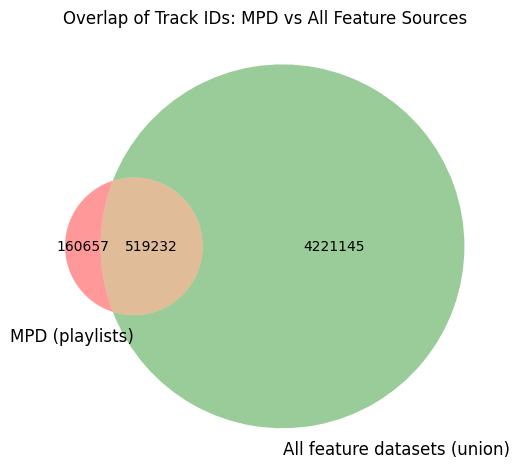

In [7]:
n_feat_union = len(ids_features_union)
intersection_union = mpd_track_ids & ids_features_union
n_inter_union = len(intersection_union)

print(f"Unique track IDs in MPD:                    {n_mpd:,}")
print(f"Unique track IDs in features UNION:         {n_feat_union:,}")
print(f"Overlap (tracks in both):                   {n_inter_union:,}")
print(f"  - % of MPD tracks covered by UNION:       {n_inter_union / n_mpd * 100:.2f}%")
print(f"  - % of UNION tracks that appear in MPD:   {n_inter_union / n_feat_union * 100:.2f}%")

plt.figure(figsize=(6, 6))
venn2(
    subsets=(
        n_mpd - n_inter_union,        # MPD only
        n_feat_union - n_inter_union, # Features only
        n_inter_union                 # Both
    ),
    set_labels=("MPD (playlists)", "All feature datasets (union)")
)
plt.title("Overlap of Track IDs: MPD vs All Feature Sources")
plt.show()


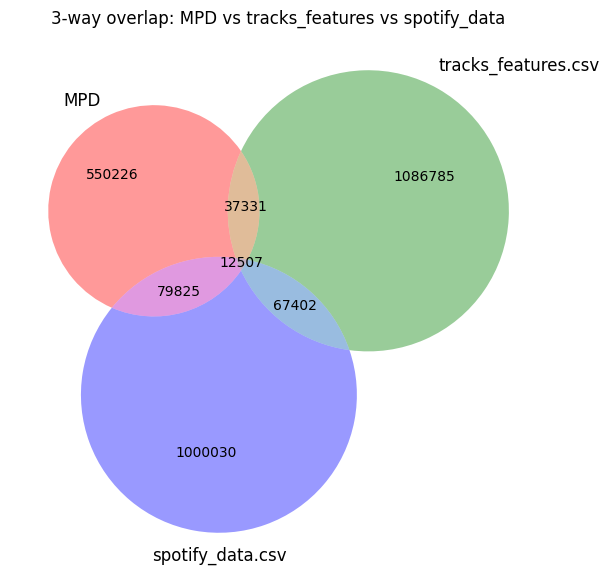

In [8]:
from matplotlib_venn import venn2, venn3

plt.figure(figsize=(7, 7))

venn3(
    subsets=(
        mpd_track_ids,          # Set A: MPD
        ids_tracks_features,    # Set B: tracks_features.csv
        ids_spotify_data        # Set C: spotify_data.csv
    ),
    set_labels=("MPD", "tracks_features.csv", "spotify_data.csv"),
)

plt.title("3-way overlap: MPD vs tracks_features vs spotify_data")
plt.show()


<span style="font-family: 'Times New Roman', Times, serif; line-height: 1.2;">

## 6. Dataset Overlap Analysis

Examining redundancy and unique coverage across feature sources.
</span>

In [9]:
# Create a CSV-only union (everything except the 2mil JSON)
ids_csv_union = (
    ids_tracks_features
    | ids_spotify_data
    | ids_spotify_2023
    | ids_tracks
    | ids_278k
    | ids_data
    | ids_raw_songs
    | ids_april_2019
    | ids_music_info
    | ids_music
    | ids_songs_audio
)

print("CSV union size:", len(ids_csv_union))


CSV union size: 3561100


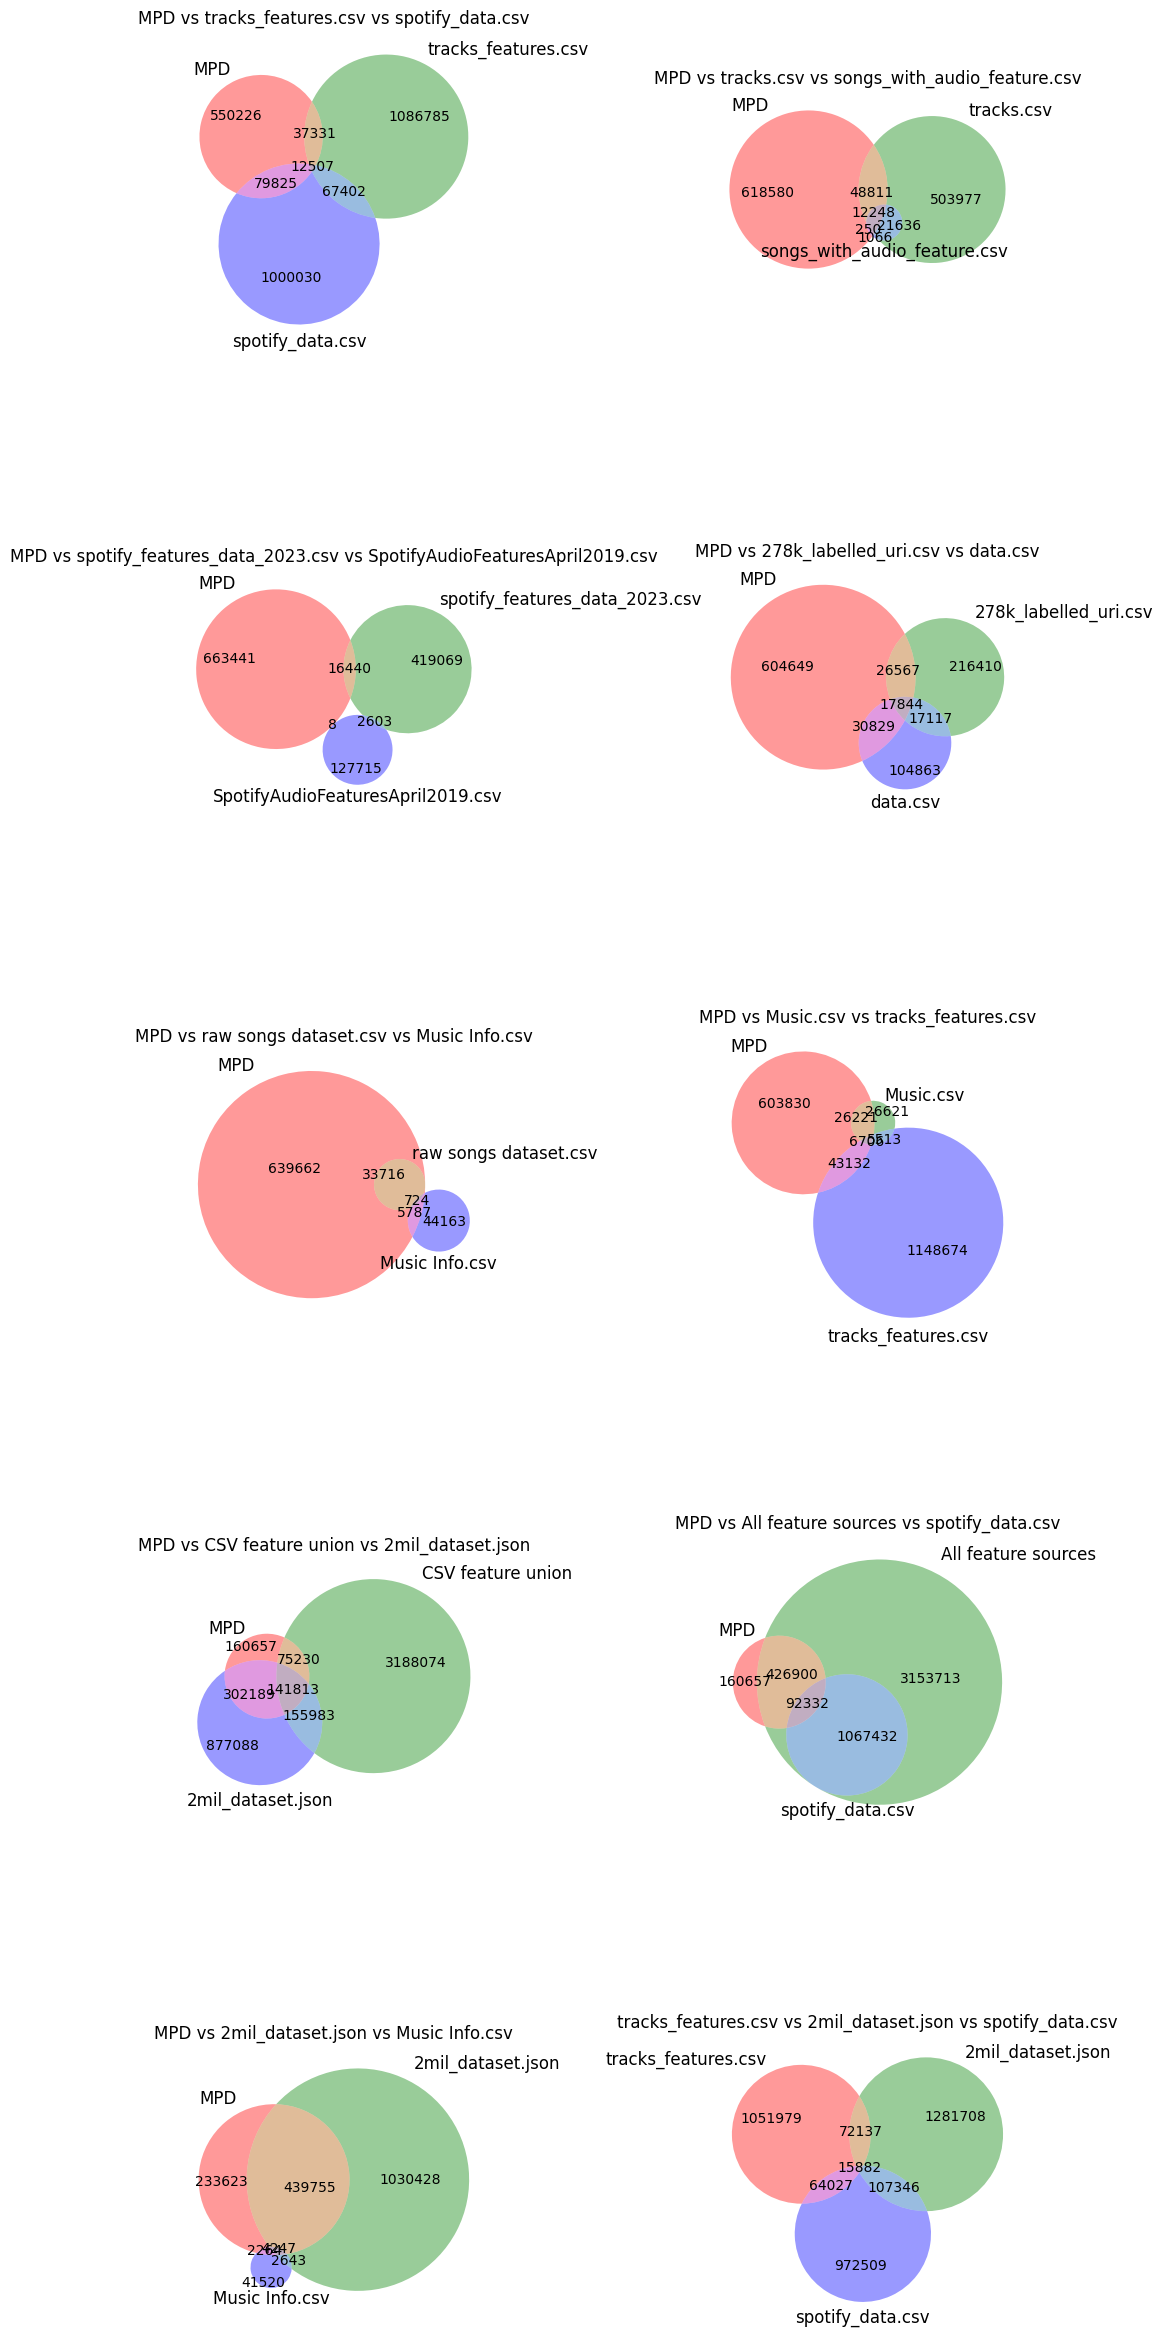

In [10]:
# (labels, varnames)
triples = [
    (("MPD", "tracks_features.csv", "spotify_data.csv"),
     ("mpd_track_ids", "ids_tracks_features", "ids_spotify_data")),

    (("MPD", "tracks.csv", "songs_with_audio_feature.csv"),
     ("mpd_track_ids", "ids_tracks", "ids_songs_audio")),

    (("MPD", "spotify_features_data_2023.csv", "SpotifyAudioFeaturesApril2019.csv"),
     ("mpd_track_ids", "ids_spotify_2023", "ids_april_2019")),

    (("MPD", "278k_labelled_uri.csv", "data.csv"),
     ("mpd_track_ids", "ids_278k", "ids_data")),

    (("MPD", "raw songs dataset.csv", "Music Info.csv"),
     ("mpd_track_ids", "ids_raw_songs", "ids_music_info")),

    (("MPD", "Music.csv", "tracks_features.csv"),
     ("mpd_track_ids", "ids_music", "ids_tracks_features")),

    (("MPD", "CSV feature union", "2mil_dataset.json"),
     ("mpd_track_ids", "ids_csv_union", "ids_2mil")),

    (("MPD", "All feature sources", "spotify_data.csv"),
     ("mpd_track_ids", "ids_features_union", "ids_spotify_data")),

    (("MPD", "2mil_dataset.json", "Music Info.csv"),
     ("mpd_track_ids", "ids_2mil", "ids_music_info")),

    (("tracks_features.csv", "2mil_dataset.json", "spotify_data.csv"),
     ("ids_tracks_features", "ids_2mil", "ids_spotify_data")),
]

# Compute grid size: 3 columns
n = len(triples)
cols = 2
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(cols * 5, rows * 5))

# Flatten axes for easier indexing
axes = axes.flatten()

for i, ((labA, labB, labC), (varA, varB, varC)) in enumerate(triples):
    ax = axes[i]
    
    # Skip missing sets safely
    if varA not in globals() or varB not in globals() or varC not in globals():
        ax.text(0.5, 0.5, f"Missing: {varA}/{varB}/{varC}", ha='center')
        ax.axis("off")
        continue

    setA = globals()[varA]
    setB = globals()[varB]
    setC = globals()[varC]

    plt.sca(ax)
    venn3(
        subsets=(setA, setB, setC),
        set_labels=(labA, labB, labC)
    )
    ax.set_title(f"{labA} vs {labB} vs {labC}")

# Turn off any unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()


<span style="font-family: 'Times New Roman', Times, serif; line-height: 1.2;">

### 6.1 Comprehensive Pairwise Comparisons

Systematic analysis of all dataset pairs to identify redundancy.
</span>

Total pairwise Venn diagrams: 66
Page 1: plotting 66 diagrams


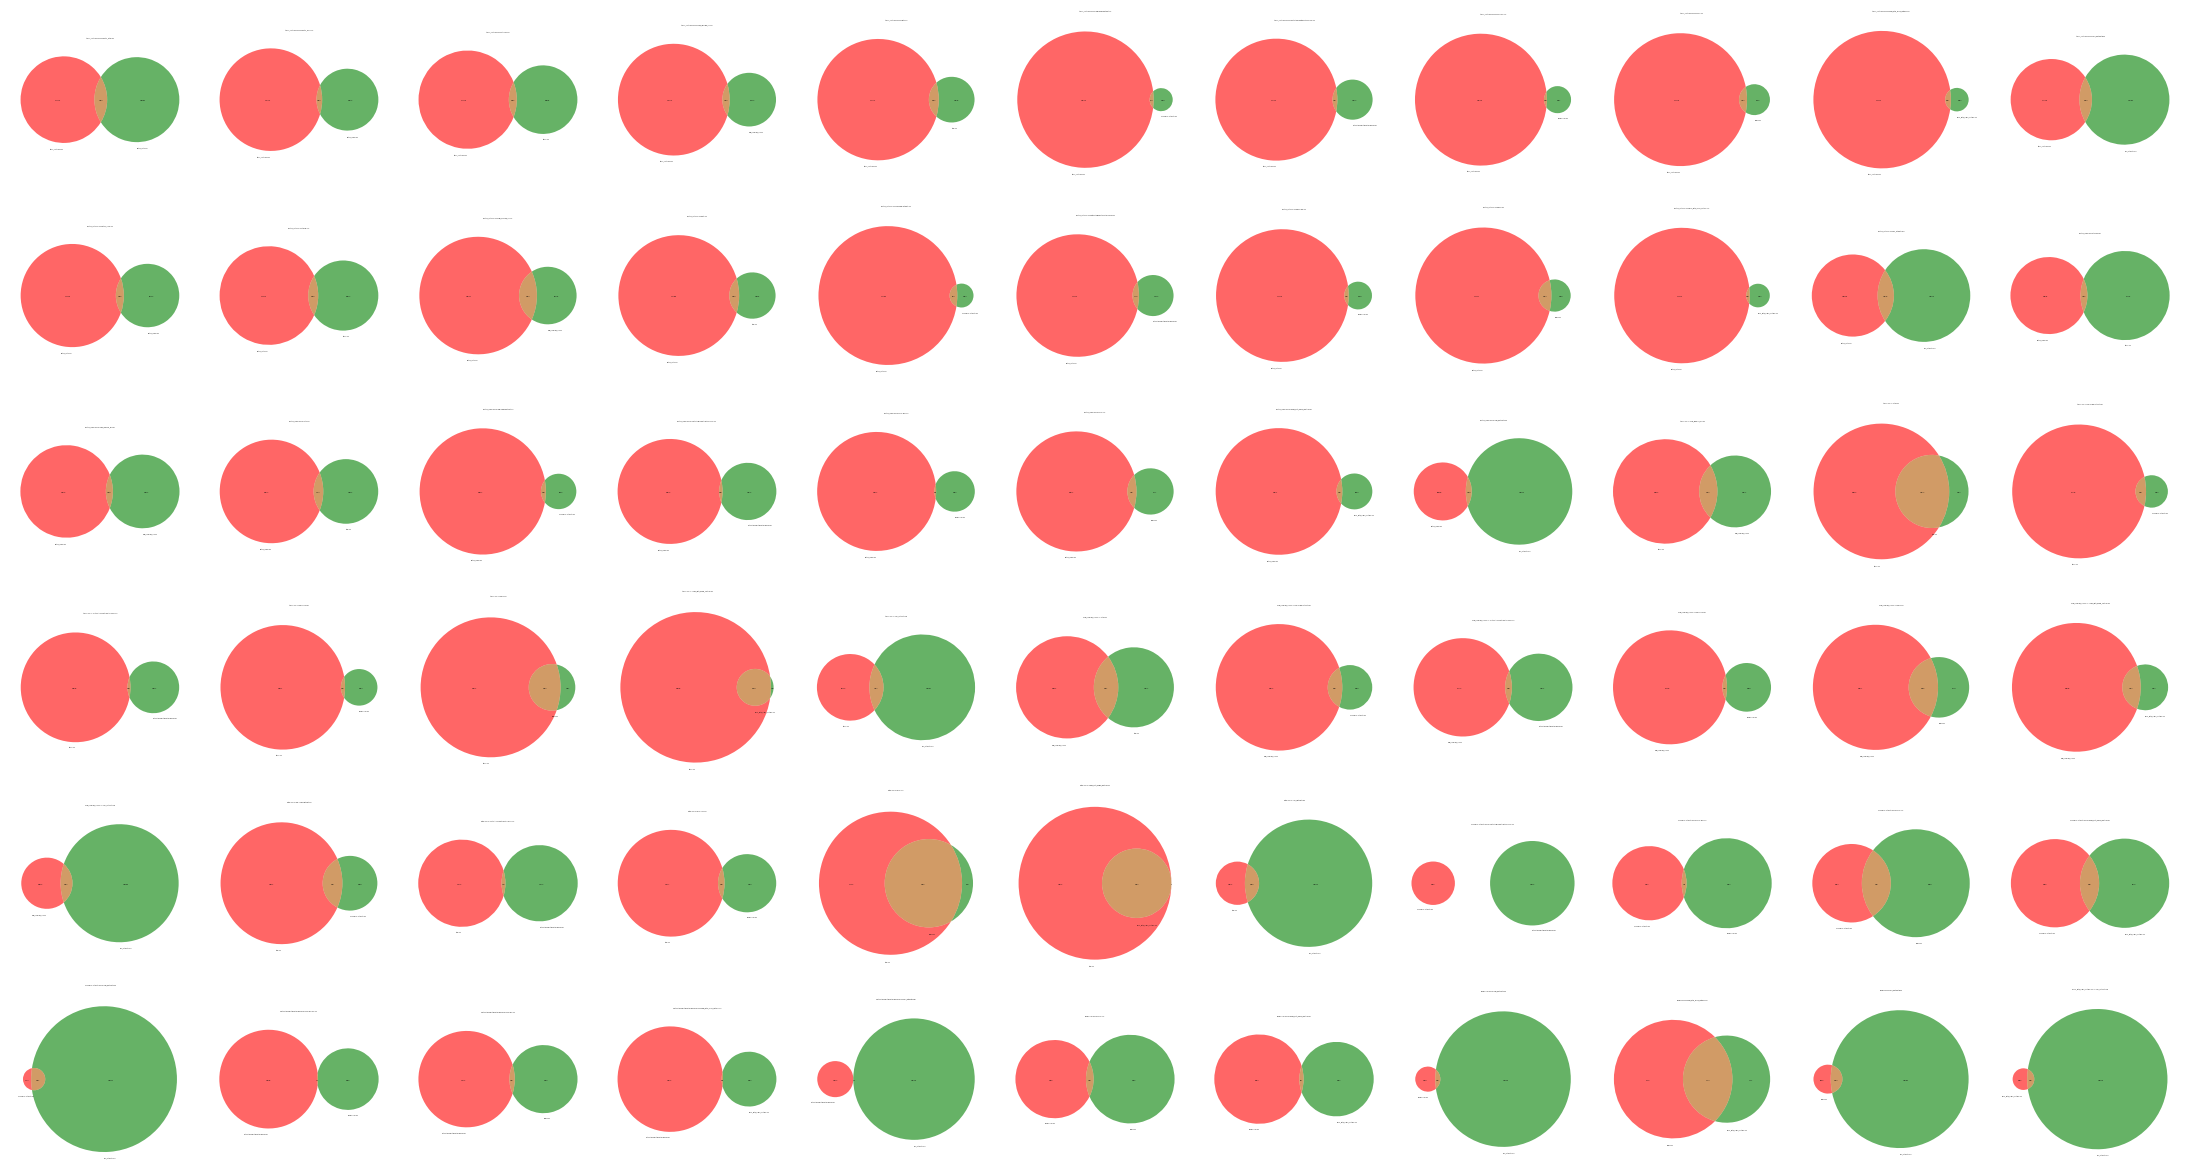

In [11]:
# from matplotlib_venn import venn2
from itertools import combinations
import numpy as np
import matplotlib.pyplot as plt

FIG_COLS = 11
FIG_ROWS = 6
FIG_WIDTH_PER_COL = 2
FIG_HEIGHT_PER_ROW = 2

LABEL_FONTSIZE  = 1
REGION_FONTSIZE = 1
TITLE_FONTSIZE  = 1


sets_info = [
    #("MPD",                     "mpd_track_ids"),
    ("tracks_features.csv",     "ids_tracks_features"),
    ("spotify_data.csv",        "ids_spotify_data"),
    ("spotify_2023.csv",        "ids_spotify_2023"),
    ("tracks.csv",              "ids_tracks"),
    ("278k_labelled_uri.csv",   "ids_278k"),
    ("data.csv",                "ids_data"),
    ("raw songs dataset.csv",   "ids_raw_songs"),
    ("SpotifyAudioFeaturesApril2019.csv", "ids_april_2019"),
    ("Music Info.csv",          "ids_music_info"),
    ("Music.csv",               "ids_music"),
    ("songs_with_audio_feature.csv", "ids_songs_audio"),
    ("2mil_dataset.json",       "ids_2mil"),
    #("CSV union",               "ids_csv_union"),
    #("ALL features",            "ids_features_union"),
]

pairs = list(combinations(sets_info, 2))
print(f"Total pairwise Venn diagrams: {len(pairs)}")

PAIRS_PER_FIG = FIG_COLS * FIG_ROWS

for page_start in range(0, len(pairs), PAIRS_PER_FIG):
    page_pairs = pairs[page_start:page_start + PAIRS_PER_FIG]
    page_index = page_start // PAIRS_PER_FIG + 1

    fig, axes = plt.subplots(
        FIG_ROWS,
        FIG_COLS,
        figsize=(FIG_COLS * FIG_WIDTH_PER_COL, FIG_ROWS * FIG_HEIGHT_PER_ROW),
    )

    if isinstance(axes, np.ndarray):
        axes = axes.flatten()
    else:
        axes = [axes]

    print(f"Page {page_index}: plotting {len(page_pairs)} diagrams")

    for i, ((labelA, varA), (labelB, varB)) in enumerate(page_pairs):
        ax = axes[i]

        if varA not in globals() or varB not in globals():
            ax.text(0.5, 0.5, f"Missing: {varA}/{varB}", ha="center", va="center")
            ax.axis("off")
            continue

        setA = globals()[varA]
        setB = globals()[varB]

        ax.set_xlim(-0.1, 1.1)
        ax.set_ylim(-0.1, 1.1)

        plt.sca(ax)
        v = venn2(
            subsets=(setA, setB),
            set_labels=(labelA, labelB),
            alpha=0.6,
        )

        for region_id in ["10", "01", "11"]:
            label = v.get_label_by_id(region_id)
            if label is not None:
                label.set_fontsize(REGION_FONTSIZE)

        if v.get_label_by_id("A") is not None:
            v.get_label_by_id("A").set_fontsize(LABEL_FONTSIZE)
        if v.get_label_by_id("B") is not None:
            v.get_label_by_id("B").set_fontsize(LABEL_FONTSIZE)

        ax.set_title(f"{labelA} vs {labelB}", fontsize=TITLE_FONTSIZE)

    for j in range(len(page_pairs), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()


<span style="font-family: 'Times New Roman', Times, serif; line-height: 1.2;">

### 6.2 Quantitative Overlap Statistics

Detailed metrics on dataset intersections and potential redundancy.
</span>

In [12]:
import pandas as pd
from itertools import combinations

datasets_for_overlap = {
    "MPD":                     "mpd_track_ids",  
    "tracks_features.csv":     "ids_tracks_features",
    "spotify_data.csv":        "ids_spotify_data",
    "spotify_2023.csv":        "ids_spotify_2023",
    "tracks.csv":              "ids_tracks",
    "278k_labelled_uri.csv":   "ids_278k",
    "data.csv":                "ids_data",
    "raw songs dataset.csv":   "ids_raw_songs",
    "SpotifyAudioFeaturesApril2019.csv": "ids_april_2019",
    "Music Info.csv":          "ids_music_info",
    "Music.csv":               "ids_music",
    "songs_with_audio_feature.csv": "ids_songs_audio",
    "2mil_dataset.json":       "ids_2mil",
}

ds_sets = {}
for name, var in datasets_for_overlap.items():
    if var not in globals():
        print(f"WARNING: {var} not found in globals(), skipping {name}")
        continue
    ds_sets[name] = globals()[var]

print(f"Included {len(ds_sets)} datasets in pairwise overlap analysis.\n")



rows = []

for (name_a, set_a), (name_b, set_b) in combinations(ds_sets.items(), 2):
    size_a = len(set_a)
    size_b = len(set_b)
    inter = len(set_a & set_b)
    
    pct_a_in_b = (inter / size_a * 100) if size_a > 0 else 0.0
    pct_b_in_a = (inter / size_b * 100) if size_b > 0 else 0.0
    jaccard = (inter / len(set_a | set_b) * 100) if (size_a + size_b - inter) > 0 else 0.0
    
    rows.append({
        "A": name_a,
        "B": name_b,
        "size_A": size_a,
        "size_B": size_b,
        "intersection": inter,
        "%A_in_B": pct_a_in_b,
        "%B_in_A": pct_b_in_a,
        "jaccard_%": jaccard,
    })

pairwise_df = pd.DataFrame(rows)

pairwise_sorted = pairwise_df.sort_values(
    by="intersection", ascending=False
).reset_index(drop=True)

print("FULL PAIRWISE OVERLAP TABLE (sorted by raw intersection size):")
display(pairwise_sorted)


THRESH = 95.0  

subset_like = pairwise_sorted[
    (pairwise_sorted["%A_in_B"] >= THRESH) |
    (pairwise_sorted["%B_in_A"] >= THRESH)
].copy()

print(f"\nPairs where one dataset is ≥{THRESH}% contained in the other:")
display(subset_like)

print("\nSubset-like pairs (for copy-paste):")
for _, row in subset_like.iterrows():
    print(
        f"A='{row['A']}', B='{row['B']}', "
        f"%A_in_B={row['%A_in_B']:.2f}, %B_in_A={row['%B_in_A']:.2f}, "
        f"intersection={row['intersection']}"
    )


Included 13 datasets in pairwise overlap analysis.

FULL PAIRWISE OVERLAP TABLE (sorted by raw intersection size):


,A,B,size_A,size_B,intersection,%A_in_B,%B_in_A,jaccard_%
0,MPD,2mil_dataset.json,679889,1477073,444002,65.305072,30.059584,25.920162
1,tracks.csv,data.csv,586672,170653,126293,21.527020,74.005731,20.013724
2,spotify_data.csv,2mil_dataset.json,1159764,1477073,123228,10.625265,8.342716,4.902433
3,MPD,spotify_data.csv,679889,1159764,92332,13.580452,7.961275,5.284204
4,tracks_features.csv,2mil_dataset.json,1204025,1477073,88019,7.310396,5.959015,3.394382
...,...,...,...,...,...,...,...,...
73,SpotifyAudioFeaturesApril2019.csv,songs_with_audio_feature.csv,130326,35200,200,0.153461,0.568182,0.120973
74,SpotifyAudioFeaturesApril2019.csv,Music Info.csv,130326,50674,138,0.105888,0.272329,0.076301
75,SpotifyAudioFeaturesApril2019.csv,2mil_dataset.json,130326,1477073,13,0.009975,0.000880,0.000809
76,MPD,SpotifyAudioFeaturesApril2019.csv,679889,130326,8,0.001177,0.006138,0.000987



Pairs where one dataset is ≥95.0% contained in the other:


,A,B,size_A,size_B,intersection,%A_in_B,%B_in_A,jaccard_%
18,data.csv,songs_with_audio_feature.csv,170653,35200,35200,20.626652,100.000000,20.626652
20,MPD,raw songs dataset.csv,679889,34440,34440,5.065533,100.000000,5.065533
21,tracks.csv,songs_with_audio_feature.csv,586672,35200,33884,5.775629,96.261364,5.762703



Subset-like pairs (for copy-paste):
A='data.csv', B='songs_with_audio_feature.csv', %A_in_B=20.63, %B_in_A=100.00, intersection=35200
A='MPD', B='raw songs dataset.csv', %A_in_B=5.07, %B_in_A=100.00, intersection=34440
A='tracks.csv', B='songs_with_audio_feature.csv', %A_in_B=5.78, %B_in_A=96.26, intersection=33884


<span style="font-family: 'Times New Roman', Times, serif; line-height: 1.2;">

## 7. Feature Completeness Check

Verifying which datasets contain the core audio features needed for recommendations.
</span>

In [13]:
import pandas as pd

# Core audio feature columns
required_cols = [
    "danceability",
    "energy",
    "key",
    "loudness",
    "mode",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
]


datasets = {
    "tracks_features.csv":              tracks_features_df,
    "spotify_data.csv":                 spotify_data_df,
    "spotify_features_data_2023.csv":   spotify_2023_df,
    "tracks.csv":                       tracks_df,
    "278k_labelled_uri.csv":            k278_df,
    "data.csv":                         data_df,
    "raw songs dataset.csv":            raw_songs_df,
    "SpotifyAudioFeaturesApril2019.csv": april_2019_df,
    "Music Info.csv":                   music_info_df,
    "Music.csv":                        music_df,
    "songs_with_audio_feature.csv":     songs_audio_df,
    "2mil_dataset.json":                dataset_2mil_df,
}

rows = []

for name, df in datasets.items():
    present = {col: (col in df.columns) for col in required_cols}
    missing_cols = [col for col, ok in present.items() if not ok]
    rows.append({
        "dataset": name,
        **present,
        "n_missing": len(missing_cols),
        "missing_cols": ", ".join(missing_cols),
    })

features_check_df = pd.DataFrame(rows).sort_values("n_missing").reset_index(drop=True)

print("Core audio feature column presence by dataset:")
display(features_check_df)


Core audio feature column presence by dataset:


,dataset,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,n_missing,missing_cols
0,tracks_features.csv,True,True,True,True,True,True,True,True,True,True,True,0,
1,spotify_data.csv,True,True,True,True,True,True,True,True,True,True,True,0,
2,spotify_features_data_2023.csv,True,True,True,True,True,True,True,True,True,True,True,0,
3,tracks.csv,True,True,True,True,True,True,True,True,True,True,True,0,
4,data.csv,True,True,True,True,True,True,True,True,True,True,True,0,
5,raw songs dataset.csv,True,True,True,True,True,True,True,True,True,True,True,0,
6,SpotifyAudioFeaturesApril2019.csv,True,True,True,True,True,True,True,True,True,True,True,0,
7,Music Info.csv,True,True,True,True,True,True,True,True,True,True,True,0,
8,2mil_dataset.json,True,True,True,True,True,True,True,True,True,True,True,0,
9,songs_with_audio_feature.csv,True,True,True,True,True,True,True,True,True,True,True,0,
